# MNIST Dataset

MNIST is a dataset of **70,000 handwritten digit images** from 0 to 9.

Each image is **28 × 28 pixels**, resulting in **784 features** after flattening the image into a one-dimensional array.

* `X` → pixel values of the images
* `y` → corresponding digit labels
* Each pixel is a grayscale intensity value between **0 and 255**

The `sklearn.datasets` package provides three main types of functions:

* `fetch_*` → download real-world datasets.
* `load_*` → load small datasets bundled with Scikit-Learn.
* `make_*` → generate synthetic datasets for testing and experimentation.

Datasets may be returned as NumPy arrays, `(X, y)` tuples, or `Bunch` objects.

`fetch_openml()` returns Pandas objects by default, but `as_frame=False` can be used to get NumPy arrays, which is more convenient for datasets such as MNIST.



In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

X, y = mnist.data, mnist.target

Some Scikit-Learn datasets are returned as a `Bunch` object, which behaves like a dictionary and also allows attribute-style access.

Common entries include:

* `DESCR` → description of the dataset
* `data` → input features, usually a 2D NumPy array
* `target` → target labels, usually a 1D NumPy array


In [2]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [3]:
print(X.shape, X.dtype, sep=" | ")
print(y.shape, y.dtype, sep=" | ")


(70000, 784) | int64
(70000,) | object


In [4]:
y[0]

'5'

In [5]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

The output is not suitable for visualizing as an image, so let's reshape it back to its original `28 × 28` format.

# Reshaping MNIST Images

Each MNIST image is stored as a 1D array of 784 pixel values.

To visualize an image, we reshape it back to its original `28 × 28` format:

`784 → 28 × 28`

`reshape()` changes the shape of the array without changing its values.


In [6]:
X[10].reshape(28, 28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118,
        219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254,
        254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

# Visualizing MNIST Images

A helper function can be used to reshape a flattened MNIST image back to `28 × 28` and display it with Matplotlib.

This makes it easy to visualize different samples by passing their flattened pixel data to the function.


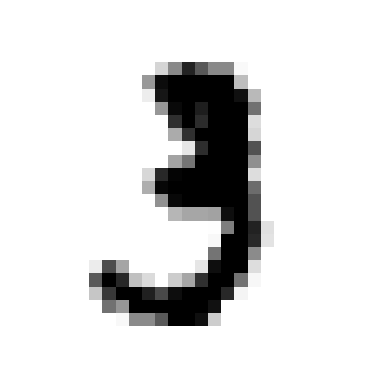

In [7]:
import matplotlib.pyplot as plt


def show_image(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()


some_digit = X[10]
show_image(some_digit)

In [8]:
y[10]

'3'

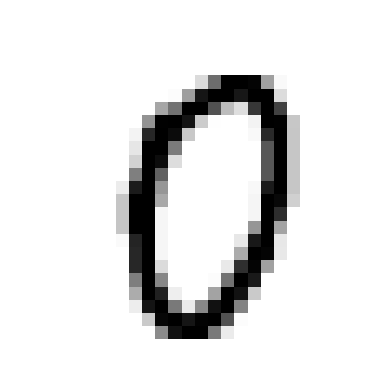

In [9]:
show_image(X[1000])

In [10]:
y[1000]

'0'

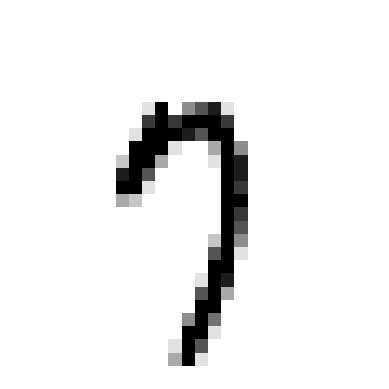

In [11]:
show_image(X[50021])

In [12]:
y[50021]

'7'

# MNIST Train/Test Split

The MNIST dataset already provides a standard split:

* **60,000 images** → training set
* **10,000 images** → test set

The test set should be kept separate and untouched until the final evaluation to avoid **data leakage** and obtain a reliable estimate of the model's generalization performance.


In [13]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
some_digit = X_train[10]

# Shuffling the Training Set

The MNIST training set is already shuffled.

Shuffling helps ensure that:

* Cross-validation folds contain a representative mix of classes.
* Order-sensitive learning algorithms do not receive many similar samples consecutively.

Shuffling is especially important for algorithms that process training instances sequentially, such as **Stochastic Gradient Descent (SGD)**.


# Training a Binary Classifier with SGD

For this classification task, we train an `SGDClassifier` to distinguish between the digit **3** and all other digits.

* **Classifier:** A model that assigns an input to a class.
* **Binary classification:** A classification problem with two classes: `3` and `not 3`.
* **SGD:** A method used to train the classifier.
* **`fit()`:** Trains the classifier using the training data and their corresponding target labels.

In [14]:
from sklearn.linear_model import SGDClassifier

y_train_3 = (y_train == "3") # True for all 3s, False for all other digits
y_test_3 = (y_test == "3")

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_3)

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.Integer values must be in the range `[0, 2**32 - 1]`.",42
,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only i

After training, the classifier can make predictions for new images:

`predict()` expects a collection of samples. Since `some_digit` represents one image with **784 features**, wrapping it in a list changes its shape from `(784,)` to 

`(1, 784)`, meaning **1 sample with 784 features**.


In [15]:
sgd_clf.predict([some_digit])

array([ True])

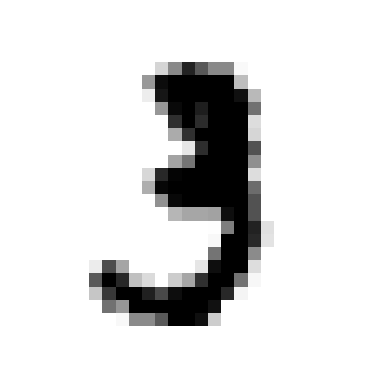

In [16]:
show_image(some_digit)

In [17]:
sgd_clf.predict([X[122]])

array([False])

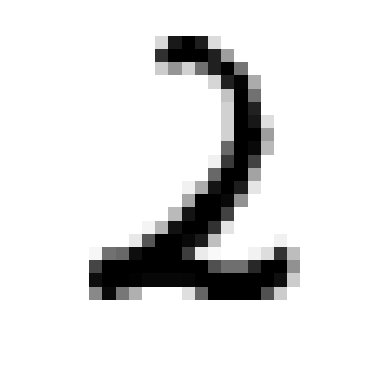

In [18]:
show_image(X[122])

In [19]:
X[0].shape

(784,)

# Evaluating a Classifier with Cross-Validation

`cross_val_score()` can be used to evaluate a classifier using k-fold cross-validation.

With `cv=3`, the training set is divided into three folds. The model is trained and evaluated three times, using a different fold for evaluation each time.

The `scoring="accuracy"` argument measures the percentage of correct predictions.

In [20]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_3, cv=3, scoring="accuracy")

array([0.9496 , 0.9624 , 0.96275])

The classifier achieves about **95–96% accuracy across the three cross-validation folds**.

# DummyClassifier
`DummyClassifier` is used as a simple baseline model. In this example, it predicts the majority class (`not 3`) for every image without learning any meaningful pattern from the pixel features.

The `any()` function checks whether there is at least one `True` value among the predictions. Therefore, if the result is `False`, it means that `DummyClassifier` predicted `not 3` for every image in the training set and did not identify a single image as `3`.

This demonstrates why a high accuracy score can be misleading when the classes are imbalanced.


In [21]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_3)
any(dummy_clf.predict(X_train))

False

In [22]:
cross_val_score(dummy_clf, X_train, y_train_3, cv=3, scoring="accuracy")

array([0.89785, 0.8978 , 0.8978 ])

In [23]:
y_train_3.sum() / y_train_3.size

np.float64(0.10218333333333333)

Cross-validation gives about **90% accuracy** because approximately **90%** of the training images belong to the `not 3` class.

The class distribution confirms that this high accuracy comes from the imbalance between the two classes, not from learning useful patterns from the images.

# Generating Out-of-Sample Predictions

Before creating a **Confusion Matrix**, we need predictions that can be fairly compared with the actual target labels.

The `cross_val_predict()` function uses **k-fold cross-validation** to generate **out-of-sample predictions** for every training instance.

With `cv=3`, the training set is divided into three folds. The classifier is trained three times:

1. Train on Folds 2 and 3 → predict Fold 1
2. Train on Folds 1 and 3 → predict Fold 2
3. Train on Folds 1 and 2 → predict Fold 3

In [24]:
from sklearn.model_selection import cross_val_predict

y_train_prediction = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3)
y_train_prediction

array([False, False, False, ..., False, False, False], shape=(60000,))

Each instance is therefore predicted by a model that **did not see that instance during training**.

The predictions from all three folds are combined into a single array. The order of these predictions corresponds to the order of `X_train`.

These **out-of-sample predictions** can then be compared with the actual labels to construct a **Confusion Matrix**

In [25]:
y_train_prediction[10]

np.True_

In [26]:
y_train[10]

'3'

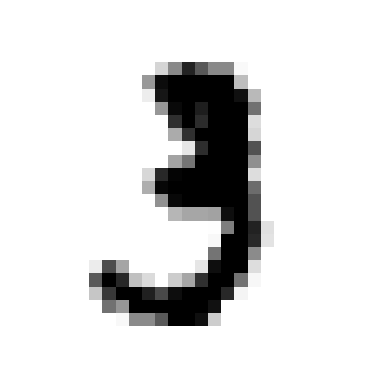

In [27]:
show_image(some_digit)

# Confusion Matrix

A **Confusion Matrix** shows how a classifier's predictions compare with the actual target labels. It counts how many instances of each actual class were classified as each predicted class.

For binary classification, the matrix contains four outcomes:

| Actual   | Predicted | Result                  |
| -------- | --------- | ----------------------- |
| Positive | Positive  | **True Positive (TP)**  |
| Negative | Positive  | **False Positive (FP)** |
| Positive | Negative  | **False Negative (FN)** |
| Negative | Negative  | **True Negative (TN)**  |

The rows represent the **actual classes**, while the columns represent the **predicted classes**.

```text
                  Predicted
                Negative   Positive
Actual Negative    TN         FP
       Positive    FN         TP
```

* **TP:** The classifier correctly predicts a positive instance.
* **TN:** The classifier correctly predicts a negative instance.
* **FP:** The classifier predicts positive, but the instance is actually negative.
* **FN:** The classifier predicts negative, but the instance is actually positive.

The main diagonal contains the **correct predictions** (`TN` and `TP`), while the off-diagonal cells contain the **classification errors** (`FP` and `FN`).

A Confusion Matrix can be computed using the actual labels and the out-of-sample predictions generated by `cross_val_predict()`

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_3, y_train_prediction)
cm

array([[53477,   392],
       [ 2113,  4018]])

For **multiclass classification**, the matrix becomes larger. If there are `n` classes, the Confusion Matrix has a size of:

$$
n \times n
$$

Each row represents an actual class, and each column represents a predicted class.

In [29]:
y_train_perfect_prediction = y_train_3  # pretend we reached perfection
confusion_matrix(y_train_3, y_train_perfect_prediction)

array([[53869,     0],
       [    0,  6131]])

# Precision and Recall

Both **Precision** and **Recall** are classification metrics derived from the **Confusion Matrix**. They focus on the positive class but measure different aspects of the classifier's performance.

## Precision

**Precision** measures how reliable the classifier's positive predictions are.

In other words:

> Of all instances predicted as positive, how many were actually positive?

The formula is:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

Where:

* **TP (True Positive):** The instance is actually positive and the classifier predicts positive.
* **FP (False Positive):** The instance is actually negative, but the classifier predicts positive.

Therefore, Precision only considers instances that the classifier **predicted as positive**.

For example, suppose the classifier predicts 100 images as `3`, but only 80 of them are actually `3`:

$$
\text{Precision} = \frac{80}{80 + 20} = 80\%
$$

A higher Precision means that positive predictions are more trustworthy.

## Why Precision Alone Is Not Enough

Consider a classifier that is extremely cautious and only makes a positive prediction when it is very confident.

In the extreme case, suppose it predicts **positive for only one instance**, and that prediction is correct:

$$
\text{Precision} = \frac{1}{1} = 100\%
$$

Although the classifier has perfect Precision, it may still be very poor because it ignores almost all other positive instances.

For example, if there are 100 actual positive instances but the classifier detects only one:

$$
\text{Recall} = \frac{1}{100} = 1\%
$$

Therefore, a classifier can have **100% Precision but only 1% Recall**.

## Recall

**Recall**, also called **Sensitivity** or **True Positive Rate (TPR)**, measures the proportion of actual positive instances that the classifier correctly detects.

In other words:

> Of all actual positive instances, how many did the classifier correctly identify?

The formula is:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Where:

* **TP (True Positive):** The instance is actually positive and the classifier predicts positive.
* **FN (False Negative):** The instance is actually positive, but the classifier predicts negative.

Therefore, Recall considers **all actual positive instances**, whether the classifier detected them or missed them.

For example, if there are 100 actual positive instances and the classifier correctly detects 80:

$$
\text{Recall} = \frac{80}{80 + 20} = 80\%
$$

## Precision vs. Recall

The two metrics answer different questions:

* **Precision:** When the classifier predicts positive, how often is it correct?
* **Recall:** Of all actual positive instances, how many did the classifier detect?

$$
\boxed{\text{Precision} = \frac{TP}{TP + FP}}
$$

$$
\boxed{\text{Recall} = \frac{TP}{TP + FN}}
$$

A classifier that tries to increase Precision often becomes more cautious about making positive predictions, which can reduce Recall. Conversely, detecting more positive instances can increase Recall while potentially reducing Precision.

Therefore, **Precision and Recall are typically considered together** rather than relying on either metric alone.


In [30]:
from sklearn.metrics import precision_score, recall_score

print(precision_score(y_train_3, y_train_prediction))
print(recall_score(y_train_3, y_train_prediction))

0.9111111111111111
0.655358016636764


# F1 Score

Sometimes it is useful to combine **Precision** and **Recall** into a single metric, especially when comparing different classifiers. This metric is called the **F1 Score**.

The F1 Score is the **harmonic mean** of Precision and Recall:

$$
F_1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

Unlike the arithmetic mean, the harmonic mean gives more weight to lower values. Therefore, the F1 Score will be high only when **both Precision and Recall are relatively high**.

For example:

$$
Precision = 90\%, \quad Recall = 10\%
$$

$$
F_1 = 2 \times \frac{0.9 \times 0.1}{0.9 + 0.1} = 18\%
$$

This shows that a classifier cannot obtain a high F1 Score by having only one strong metric.

### F1 Score Is Not Always the Best Metric

F1 favors classifiers with a balance between Precision and Recall. However, in some applications, one of these metrics may be more important than the other.

* **High Precision:** Useful when False Positives are particularly costly. For example, when detecting videos that are safe for children, it may be preferable to reject some safe videos rather than allow unsafe videos.
* **High Recall:** Useful when False Negatives are particularly costly. For example, in medical diagnosis or detecting shoplifters, missing a real positive case can be more problematic than generating some false alerts.

Therefore, **F1 Score should not automatically be considered the best metric**. The appropriate metric depends on the consequences of False Positives and False Negatives in the specific application.


In [31]:
from sklearn.metrics import f1_score

f1_score(y_train_3, y_train_prediction)

0.7623565126648325

# Precision/Recall Trade-Off

The `SGDClassifier` computes a **score** for each instance and compares it with a **threshold** to make a classification decision:

* `score > threshold` → **Positive**
* `score ≤ threshold` → **Negative**

The `threshold` can be viewed as the **strictness of the classifier** when deciding whether an instance belongs to the positive class.

* **Increasing the threshold:** The classifier becomes more strict → **Precision increases**, while **Recall decreases**.
* **Decreasing the threshold:** The classifier becomes less strict → **Recall increases**, while **Precision decreases**.

Therefore, changing the threshold creates a **trade-off between Precision and Recall**.


# Decision Function

Instead of using `predict()`, the `decision_function()` method returns a **score** for each instance.

We can then choose the classification threshold ourselves:

In [32]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([1378.05599034])

If the score is greater than the threshold, the prediction is **Positive**; otherwise, it is **Negative**.

This allows us to change the threshold and control the trade-off between **Precision** and **Recall**.

In [33]:
threshold = 0
y_scores >= threshold

array([ True])

In [34]:
threshold = 3000
y_scores > threshold

array([False])

# Generating Decision Scores

The `cross_val_predict()` function can generate **out-of-sample decision scores** instead of final predictions by using `method="decision_function"`.

With `cv=3`, each training instance receives a score from a model that **did not see that instance during training**.

These scores can then be compared with different **thresholds** to control the trade-off between Precision and Recall.


In [35]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3, method="decision_function")
y_scores

array([ -8938.67345168, -17073.83659907,  -2250.42625883, ...,
       -15330.33317379, -25099.35767753, -36457.78038114], shape=(60000,))

# Calculating Precision and Recall for Different Thresholds

The `precision_recall_curve()` function calculates **Precision** and **Recall** for different decision thresholds using the actual labels and the decision scores.

It returns three arrays:

* `precisions`: Precision values for the different thresholds.
* `recalls`: Recall values for the different thresholds.
* `thresholds`: The decision thresholds used to calculate these values.

These results can later be used to visualize the **Precision/Recall trade-off** and understand how changing the threshold affects the classifier.


In [36]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_3, y_scores)

# Plotting the Precision/Recall Trade-Off

The calculated Precision and Recall values can be plotted against their corresponding decision thresholds.

The plot shows how **Precision** and **Recall** change as the classification threshold changes. A vertical line is also added to indicate the currently selected threshold.

* The **Precision** curve generally increases as the threshold increases.
* The **Recall** curve generally decreases as the threshold increases.
* The vertical line shows the current decision threshold.

This visualization makes the **Precision/Recall trade-off** easier to understand and helps us choose an appropriate threshold.


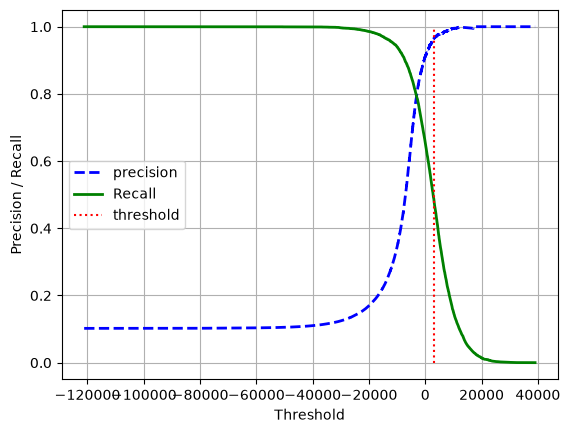

In [37]:
import matplotlib.pyplot as plt

plt.plot(thresholds, precisions[:-1], "b--", label="precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "red", "dotted", label="threshold")
plt.xlabel("Threshold")
plt.ylabel("Precision / Recall")
plt.grid()
plt.legend()
plt.show()

The `precisions` and `recalls` arrays contain **one more value than the `thresholds` array**.

The last values of `precisions` and `recalls` do not correspond to an actual decision threshold. They are added as an endpoint to complete the Precision/Recall curve.

Therefore, we use `[:-1]` when plotting so that the number of Precision and Recall values matches the number of thresholds.


When the threshold increases:

* **Recall** can only decrease or stay the same.
* **Precision** generally increases, but it can sometimes decrease.

This is why the Precision curve can be **bumpier**, while the Recall curve is usually smoother.


At this threshold value, precision is near 95% and recall is around 50%. Another way
to select a good precision/recall trade-off is to plot precision directly against recall:

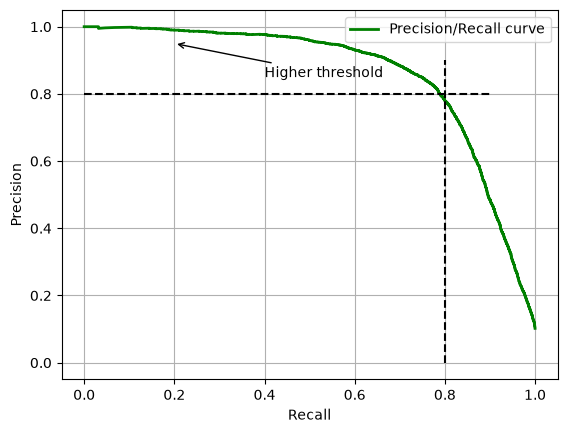

In [38]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve", c="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.vlines(
    0.8,
    0,
    0.9,
    "k",
    linestyles="dashed"
)

plt.hlines(
    0.8,
    0,
    0.9,
    "k",
    linestyles="dashed"
)

plt.annotate(
    "Higher threshold",
    xy=(0.2, 0.95),
    xytext=(0.4, 0.85),
    arrowprops=dict(arrowstyle="->")
)

plt.grid()
plt.legend()
plt.show()

# Selecting a Threshold for a Target Precision

Instead of choosing a threshold visually from the Precision/Recall plot, we can find it precisely using the calculated `precisions` and `thresholds` arrays.

Suppose we want the classifier to achieve at least **90% Precision**.

First, we identify which Precision values satisfy this condition:

`precisions >= 0.90`

This produces a Boolean array containing `True` for Precision values of at least 90% and `False` otherwise.

The `argmax()` method can then find the **first `True` value** because Boolean values are treated numerically:

* `False` → `0`
* `True` → `1`

Since the `thresholds` array is ordered from lower to higher values, the first `True` corresponds to the **lowest threshold that achieves at least 90% Precision**.

This allows us to select the required threshold precisely instead of estimating it from the plot.


In [39]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(-411.44326592496236)

In [40]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)
y_train_pred_90

array([False, False, False, ..., False, False, False], shape=(60000,))

In [41]:
precision_score(y_train_3, y_train_pred_90)

0.9000870700914236

In [42]:
recall_at_90_precision = recall_score(y_train_3, y_train_pred_90)
recall_at_90_precision

0.6744413635622247

# ROC Curve

The **ROC (Receiver Operating Characteristic) curve** is another common tool for evaluating binary classifiers.

It plots:

* **True Positive Rate (TPR)** on the y-axis, which is the same as **Recall / Sensitivity**.
* **False Positive Rate (FPR)** on the x-axis.

The **False Positive Rate** measures the proportion of actual negative instances that are incorrectly classified as positive:

$$
FPR = \frac{FP}{FP + TN}
$$

The **True Negative Rate (TNR)** measures the proportion of actual negative instances that are correctly classified as negative:

$$
TNR = \frac{TN}{TN + FP}
$$

TNR is also called **Specificity**, so:

$$
FPR = 1 - TNR = 1 - Specificity
$$

Therefore, the ROC curve can also be described as:

$$
\text{Sensitivity (Recall)} \quad \text{vs.} \quad 1 - \text{Specificity}
$$

The `roc_curve()` function can be used to calculate the **TPR and FPR for different decision thresholds**, allowing us to visualize how changing the threshold affects the classifier.

The selected threshold for **90% precision** is matched to the corresponding point on the ROC curve by finding its index in the `thresholds` array.

Because the thresholds are listed in decreasing order, `<=` is used to find the first threshold that is at or below the selected threshold. This index is then used to retrieve the corresponding **TPR** and **FPR** values.



In [43]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_3, y_scores)
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

# Plotting the ROC Curve
The ROC curve plots **TPR (Recall)** against **FPR** for different decision thresholds.

The dotted diagonal represents a **random classifier**, while the marked point shows the ROC performance at the threshold selected for **90% precision**. The curved annotation indicates the effect of increasing the classification threshold.


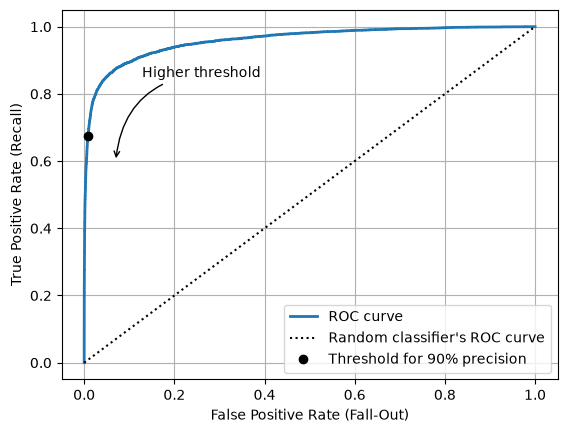

In [44]:
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.xlabel("False Positive Rate (Fall-Out)")
plt.ylabel("True Positive Rate (Recall)")
plt.grid()
plt.legend()

plt.annotate(
    "Higher threshold",
    xy=(0.07, 0.6),
    xytext=(0.26, 0.85),
    arrowprops=dict(
        arrowstyle="->",
        connectionstyle="arc3,rad=0.4"
    ),
    ha="center"
)

plt.show()

# ROC Curve vs. Precision/Recall Curve

ROC and Precision/Recall (PR) curves both show how changing the **decision threshold** affects a binary classifier, but they emphasize different aspects of performance.

## When to Prefer the PR Curve

As a rule of thumb, prefer the **PR curve** when:

* The **positive class is rare**.
* **False positives** are more important or costly than false negatives.

Otherwise, the **ROC curve** can be a suitable choice.

## Why Class Imbalance Matters

Suppose:

* 90% of the instances are `not 3`.
* Only 10% of the instances are `3`.

The ROC curve uses the **False Positive Rate (FPR)**:

$$
FPR = \frac{FP}{FP + TN}
$$

Because there are many negative instances, there can be a considerable number of **False Positives** while the FPR remains relatively small due to the large number of **True Negatives**.

As a result, the **ROC curve and ROC AUC may look very good**, even when the classifier is not particularly good at detecting the rare positive class.

The **PR curve**, on the other hand, focuses directly on **Precision and Recall**, making it more informative about the classifier's performance on the positive class when that class is rare.

> **Rule of thumb:** Rare positive class → PR curve is often more informative; otherwise, ROC curve is often suitable.

This is not an absolute rule. The choice should also depend on the specific problem and the relative cost of **False Positives** and **False Negatives**.
